# Aufgaben

In [1]:
# Import
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import pairwise_distances_argmin
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import make_blobs, make_moons
from scipy.spatial.distance import cdist
from sklearn.mixture import GaussianMixture

## Quiz-Section

## WarmUp
<div>
    <img src=attachment:1d58fba3-dd18-4609-a776-6e3d77859818.png width=100>
</div>
Let's do stretching: Kleinstaufgaben, um die gelernten Funktionen einzuüben.
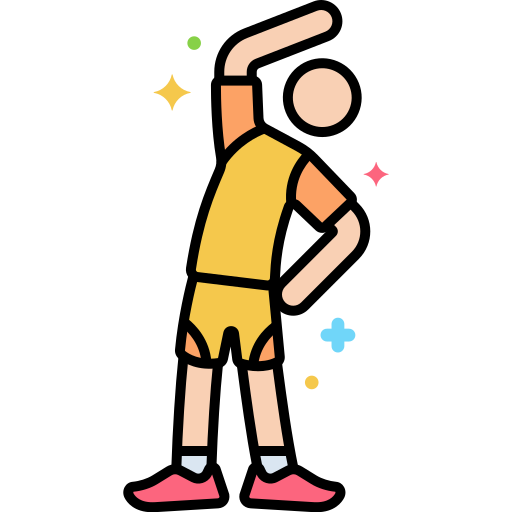

## Aufgabe: Schätzung des Betriebszustands einer Maschine 2.0

<div>
    <img src=attachment:130e47f7-bd43-4ce2-b8e5-8f5c1c984657.png width=100>
</div>

Im Beispiel "Bestimmung des Betriebszustandes von alten Brownfield-Maschinen" haben wir $k$-means Clustering verwendet, um Betriebszustände von älteren Maschinen anhand von Sensoraufzeichnungen zu erkennen. Passen Sie den Code des Beispiels so an, dass Sie anstatt des $k$-means Gausssian Mixture Models trainieren. Kommen Sie auf ein vergleichbares Ergebnis hinsichtlich des Hyperparameters? Visualisieren Sie sich das Ergebnis im Feature-Raum, indem Sie die Datenpunkte nach den Labels einfärben und die Größe der Datenpunkte im Scatter-Plot hinsichtlich der _Zuordnungswahrscheinlichkeit_ einstellen.
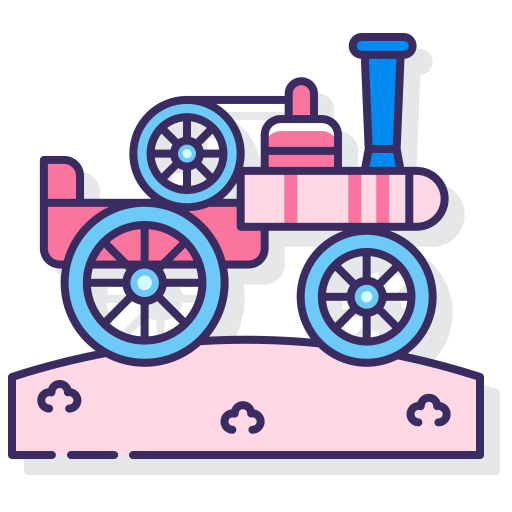

### Lösung

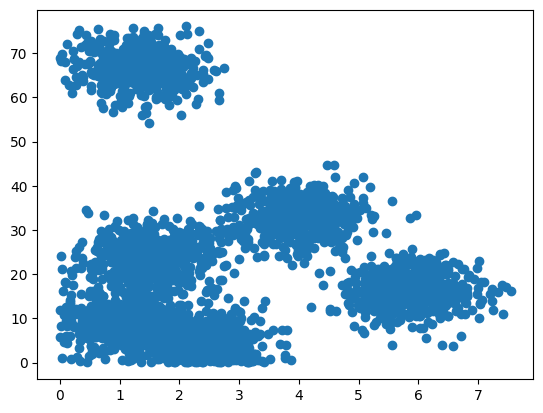

In [2]:
# Load
X = np.load('./../res/data/machine_state.npy')

# Look
plt.figure()
plt.scatter(X[:, 0], X[:, 1])

# To scale or not to scale: try both - what happens without scaling?
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
#X = scaler.fit_transform(X)

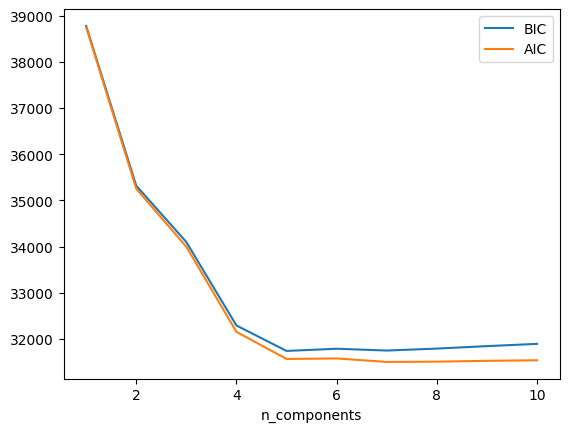

In [3]:
# Train GMM for range of components
n_components = np.arange(1, 11)
models = [GaussianMixture(n, covariance_type='full').fit(X)
          for n in n_components]

# Plot AIC/BIC
plt.plot(n_components, [m.bic(X) for m in models], label='BIC')
plt.plot(n_components, [m.aic(X) for m in models], label='AIC')
plt.legend(loc='best')
plt.xlabel('n_components');

In [4]:
bic = [m.bic(X) for m in models]
aic = [m.aic(X) for m in models]
np.argmin(aic)

np.int64(6)

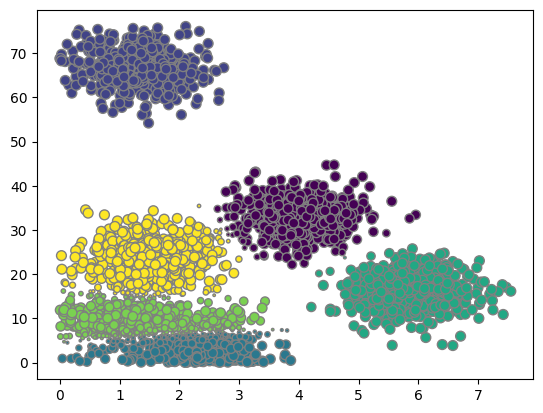

In [5]:
model = GaussianMixture(6, covariance_type='full').fit(X)
probs = model.predict_proba(X)
labels = model.predict(X)
size = 50 * probs.max(1) ** 4  # square emphasizes differences
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=size,
            edgecolors='gray');

## Aufgabe: Face Generator

<div>
    <img src=attachment:249736b0-2b83-4d56-a31a-d990fe7d1598.png width=100>
</div>

Im Beispiel "SVM and Face Recognition" haben wir uns einen Klassifikator gebaut, der gelernt hat bestimmte Gesichter voneinander zu unterscheiden. In dieser Aufgabe sollen Sie ein Gaussian Mixture Model auf den gleichen Datensatz trainieren, so dass es ihnen __neue__ Gesichter __generieren__ kann. Nutzen Sie hierzu den Code aus dem ursprünglichen Beispiel und passen Sie ihn entsprechend an. Was müssen Sie bzgl. der PCA beachten? Lassen Sie sich als Ergebnis 12 neu generierte Gesichter ausgeben.
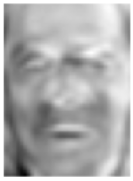

### Lösung

In [2]:
# Import
import seaborn as sns; sns.set()
from sklearn.datasets import fetch_lfw_people
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.datasets import fetch_lfw_people, make_blobs
from sklearn.metrics import accuracy_score, davies_bouldin_score, silhouette_score
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns; sns.set()
from sklearn.mixture import GaussianMixture
import numpy as np

# Get face images
lfw_people = fetch_lfw_people(min_faces_per_person=70, resize=0.4)

# Look at the structure
print(lfw_people['images'].shape)
print(lfw_people['target_names'])

(1288, 50, 37)
['Ariel Sharon' 'Colin Powell' 'Donald Rumsfeld' 'George W Bush'
 'Gerhard Schroeder' 'Hugo Chavez' 'Tony Blair']


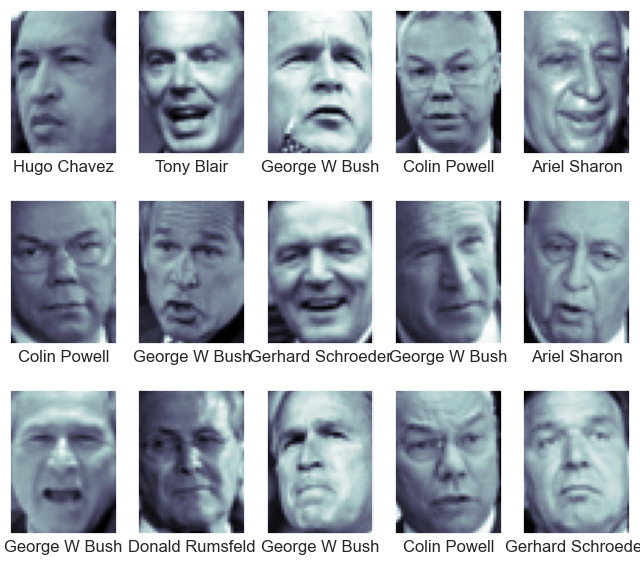

In [3]:
# Let's have a look
fig, ax = plt.subplots(3, 5, figsize=(8,7))
for i, axi in enumerate(ax.flat):
    axi.imshow(lfw_people.images[i], cmap='bone')
    axi.set(xticks=[], yticks=[],
            xlabel=lfw_people.target_names[lfw_people.target[i]])

In [4]:
# introspect the images arrays to find the shapes (for plotting)
n_samples, h, w = lfw_people['images'].shape

# Assign feature matrix
X = lfw_people['data']
n_features = X.shape[1]

# the label to predict is the id of the person
y = lfw_people['target']
target_names = lfw_people.target_names
print(target_names)

# split into a training and testing set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25)

# Compute a PCA on the face dataset
print('Computing PCA...')
n_components = 150
pca = PCA(n_components=n_components, svd_solver='randomized',
          whiten=True).fit(X_train)
X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)

['Ariel Sharon' 'Colin Powell' 'Donald Rumsfeld' 'George W Bush'
 'Gerhard Schroeder' 'Hugo Chavez' 'Tony Blair']
Computing PCA...


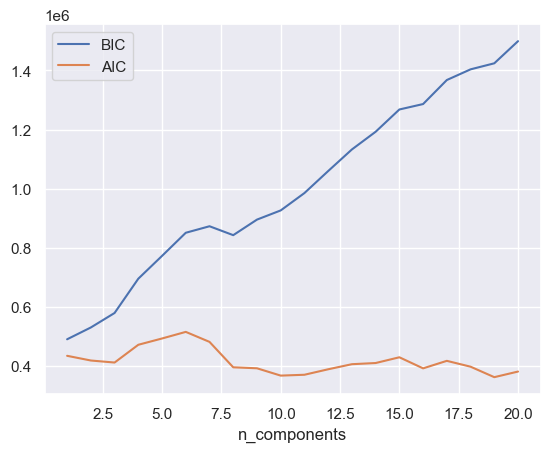

In [5]:
# Train GMM for range of components
n_components = np.arange(1, 21)
models = [GaussianMixture(n, covariance_type='full', random_state=0, reg_covar=0.0001).fit(X_train_pca)
          for n in n_components]

plt.plot(n_components, [m.bic(X_train_pca) for m in models], label='BIC')
plt.plot(n_components, [m.aic(X_train_pca) for m in models], label='AIC')
plt.legend(loc='best')
plt.xlabel('n_components');

In [7]:
# Train GMM with 7 components
model = GaussianMixture(10, covariance_type='full', random_state=0, reg_covar=0.0001).fit(X_train_pca)

# Did it converge?
print(model.converged_)

# Generate new faces
X_pca_new, y_new = model.sample(12)

# Look at the shape of newly generated data
print(X_pca_new.shape)

# So we have to do a pca inverse transform
X_new = pca.inverse_transform(X_pca_new)

# Now it works
print(X_new.shape)
print(X.shape)

True
(12, 150)
(12, 1850)
(1288, 1850)


C:\Users\gom39655\AppData\Local\anaconda3\envs\KS_new\Lib\site-packages\sklearn\mixture\_base.py:443: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  rng.multivariate_normal(mean, covariance, int(sample))


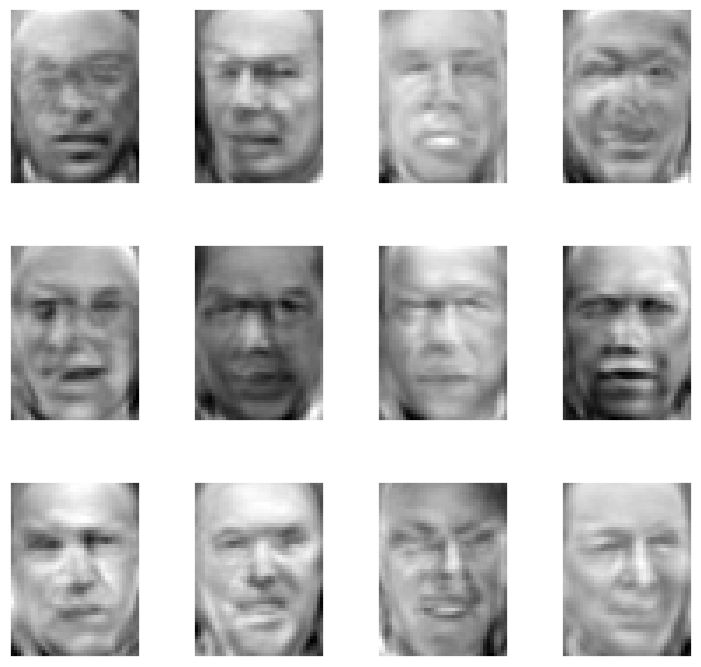

In [8]:
# Show new faces
def plot_gallery(images, h, w, n_row=3, n_col=4):
    """Helper function to plot a gallery of portraits"""
    plt.figure(figsize=(1.8 * n_col, 2.4 * n_row))
    plt.subplots_adjust(bottom=0, left=.01, right=.99, top=.90, hspace=.35)
    for i in range(n_row * n_col):
        plt.subplot(n_row, n_col, i + 1)
        plt.imshow(images[i].reshape((h, w)), cmap=plt.cm.gray)
        plt.xticks(())
        plt.yticks(())

plot_gallery(X_new, h, w);

## Aufgabe: Gehirntumorsegmentierung

<div>
    <img src=attachment:ff1f67a7-aff5-48c3-94f4-e4731c66fc15.png width=200>
</div>

Ein wichtiger Use Case für Modelle wie Gaussian Mixture Models ist die Segmentierung von Bildern. Wenn Sie an die eindimensionalen Beispiele aus der Vorlesung denken, dann sehen Sie, dass man mit GMMs Histogramme bzw. Wahrscheinlichkeitsdichten unterteilen bzw. segmentieren kann. Wenn Sie Histogramme von Bildern erzeugen - also einfach über alle Pixelwerte - dann erhalten Sie ein Histogramm, in dem sich bestimmte Bereiche als voneinander trennbare/unterscheidbare Maxima zeigen. Durch eine geeignete Zahl an Gaußkurven können dann die jeweiligen Bereiche durch einzelne Gaußkurven repräsentiert werden. Dann ist es nur noch eine Frage der Schwellwertziehung, um eine geeignete Visualisierung bzw. Segmentierung des Bildes zu erzeugen.

Ein Paradebeispiel der Medizintechnik ist die Segmentierung von Gehirntumoren in MRT-Bildern. Um tomoröses von gesundem Gewebe unterscheiden zu können, wendet man Segmentierungsverfahren auf Histogramme solche MRT-Bilder an. Dies sollen Sie in dieser Aufgabe durchführen. Trainieren Sie ein GMM am Histogramm aller Voxelwerte des vorgegebenen MRT-Bildes und entscheiden Sie, welche Anzahl an Gaußkurven Sie benötigen, um eine _optimale_ Segmentierung herzustellen. Visualisieren Sie die unterschiedlichen Segmente.
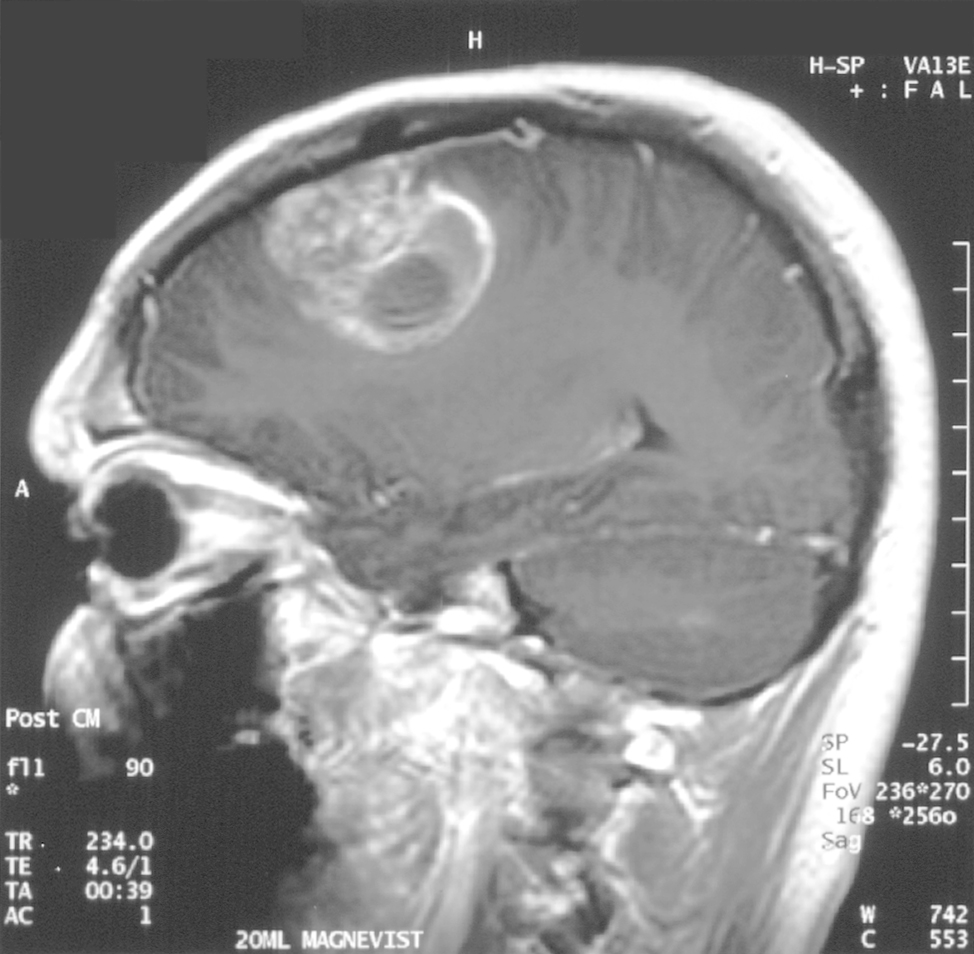

# Quellen
<div>
    <img src=attachment:7ac75623-172d-4d2d-8e47-382d3f0fc775.png width=100>
</div>
<div>Icons made by <a href="https://www.flaticon.com/authors/flat-icons" title="Flat Icons">Flat Icons</a> from <a href="https://www.flaticon.com/" title="Flaticon">www.flaticon.com</a></div>
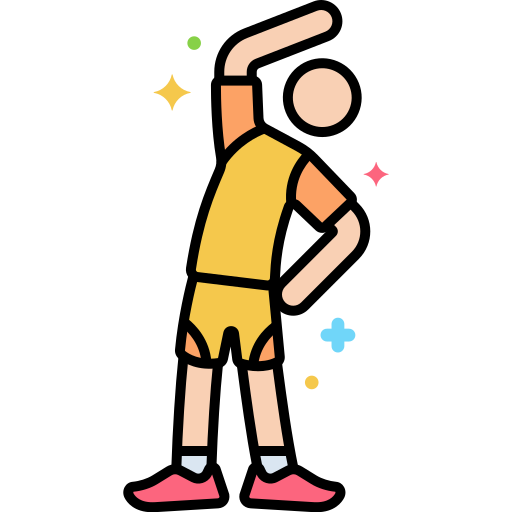

<div>
    <img src=attachment:87560295-1b17-4a34-9502-5a554cd0d9f0.png width=100>
</div>
<div>Icons made by <a href="https://www.flaticon.com/authors/flat-icons" title="Flat Icons">Flat Icons</a> from <a href="https://www.flaticon.com/" title="Flaticon">www.flaticon.com</a></div>
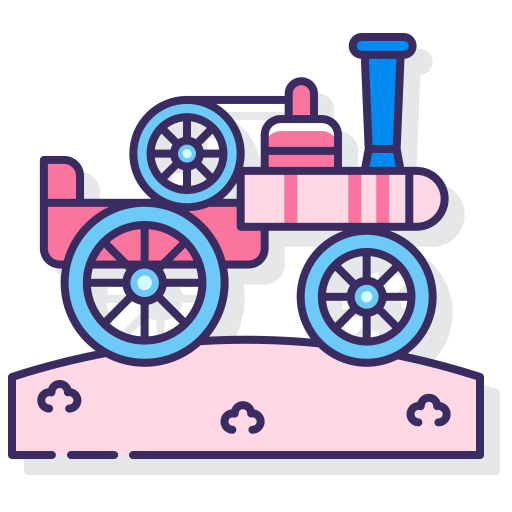

<div>
    <img src=attachment:ff1f67a7-aff5-48c3-94f4-e4731c66fc15.png width=200>
</div>
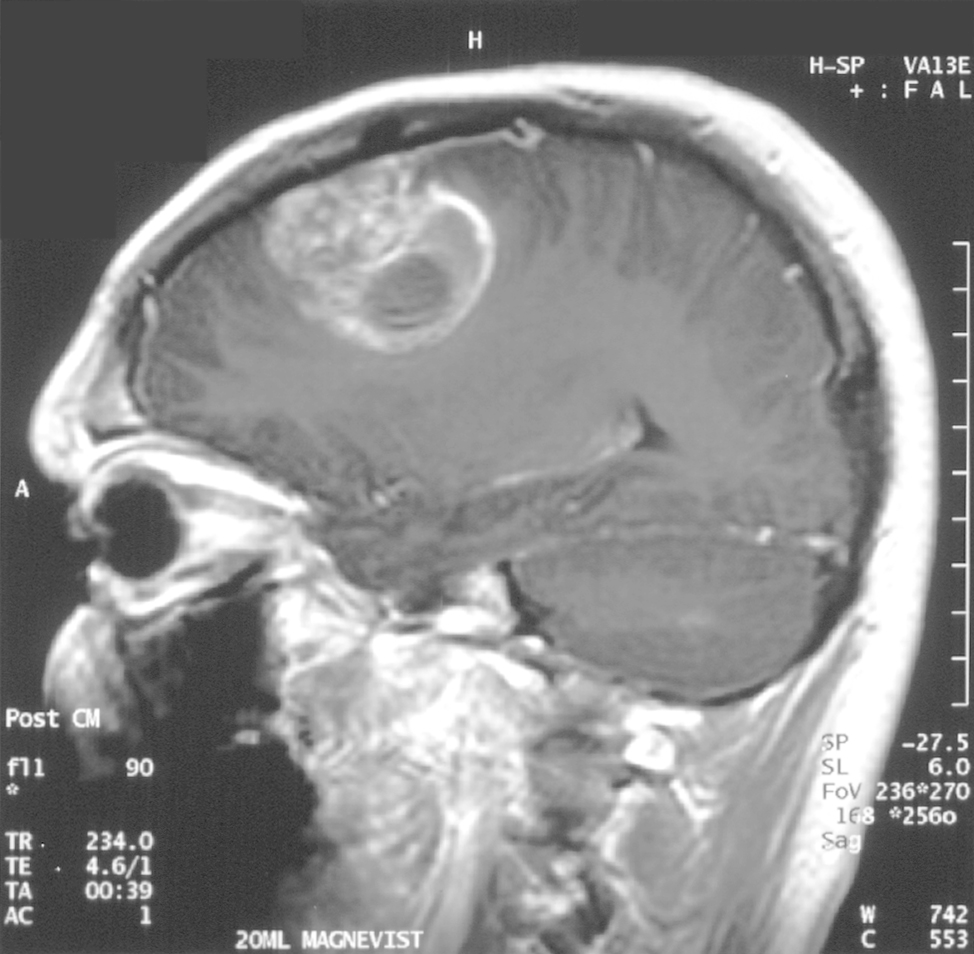

Von Christaras A - Created myself from anonymized patient MR, CC BY 2.5, https://commons.wikimedia.org/w/index.php?curid=1247038